--- SURFACE ROUGHNESS METRICS ---
Laplacian Variance Score: 5.28
(A higher raw number means deeper, more frequent physical scratches)



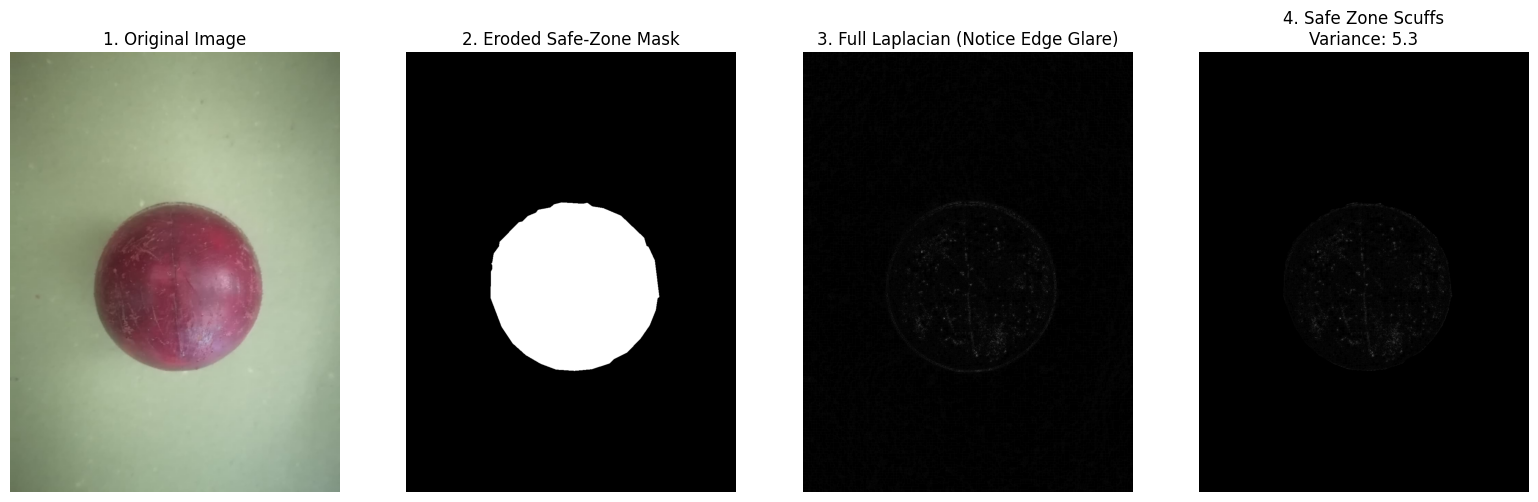

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# STEP 1: LOAD & SEGMENT (Phase 1 Logic)
# ==========================================
# Replace with your actual image path
image_path = '../data/raw/ball_2 shine side.jpg' 
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Isolate Green Grass & Invert to get the ball mask
lower_green = np.array([35, 20, 20])
higher_green = np.array([85, 255, 255])
bg_mask = cv2.inRange(hsv, lowerb=lower_green, upperb=higher_green)
mask = cv2.bitwise_not(bg_mask)

# Morphological Opening to clean pixel noise
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15,15))
opened_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
contours, _ = cv2.findContours(opened_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("Error: Could not detect the ball. Check your green HSV thresholds.")
else:
    # Get largest contour and prune it geometrically
    largest_contour = max(contours, key=cv2.contourArea)
    epsilon = 0.002 * cv2.arcLength(largest_contour, True)
    pruned_contour = cv2.approxPolyDP(largest_contour, epsilon, True)
    
    # Create Grayscale version for texture analysis
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ==========================================
    # STEP 2: THE SAFE-ZONE MASK (Erosion)
    # ==========================================
    # Create a blank black canvas the exact size of the image
    safe_mask = np.zeros_like(gray)
    
    # Draw the perfectly pruned ball in solid white
    cv2.drawContours(safe_mask, [pruned_contour], -1, 255, -1)
    
    # Erode the mask inward by 10 pixels to avoid outer boundary shadows
    erosion_kernel = np.ones((10, 10), np.uint8)
    safe_mask = cv2.erode(safe_mask, erosion_kernel, iterations=1)

    # ==========================================
    # STEP 3: THE EDGE SCANNER (Laplacian)
    # ==========================================
    # Apply a micro-blur to destroy camera sensor static/noise
    blurred_gray = cv2.GaussianBlur(gray, (3, 3), 0)
    
    # Run the Laplacian filter (calculates the 2nd derivative/sharpness)
    laplacian = cv2.Laplacian(blurred_gray, cv2.CV_64F)

    # ==========================================
    # STEP 4: THE COOKIE CUTTER & FINAL SCORE
    # ==========================================
    # Extract only the Laplacian pixel values that fall inside the white Safe Zone
    safe_laplacian_pixels = laplacian[safe_mask == 255]
    
    # Calculate the statistical variance of only those safe pixels
    variance_score = np.var(safe_laplacian_pixels)

    # ==========================================
    # STEP 5: VISUALIZATION
    # ==========================================
    print("--- SURFACE ROUGHNESS METRICS ---")
    print(f"Laplacian Variance Score: {variance_score:.2f}")
    print("(A higher raw number means deeper, more frequent physical scratches)\n")

    # Create visual versions of the maps for plotting
    lap_visual_full = cv2.convertScaleAbs(laplacian)
    
    # Create an isolated visual of just the safe zone data
    lap_isolated_visual = cv2.bitwise_and(lap_visual_full, lap_visual_full, mask=safe_mask)

    plt.figure(figsize=(16, 5))
    
    plt.subplot(1, 4, 1)
    plt.title("1. Original Image")
    plt.imshow(img_rgb)
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.title("2. Eroded Safe-Zone Mask")
    plt.imshow(safe_mask, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title("3. Full Laplacian (Notice Edge Glare)")
    plt.imshow(lap_visual_full, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.title(f"4. Safe Zone Scuffs\nVariance: {variance_score:.1f}")
    plt.imshow(lap_isolated_visual, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# calculate roughness for two sides differently


In [ ]:
class RoughnessCalculator:
    def __init__(self):
        self.edge_erosion_ratio = 0.15
        self.scuff_threshold = 25
        
        # YOUR FIX: Two distinct thresholds based on cricket physics
        self.min_pass_shine = 0.65  # Shiny side must be highly intact (65% smooth)
        self.min_pass_rough = 0.30  # Rough side is allowed to be heavily scuffed

In [ ]:
# --- NEW AGGREGATION RULE (Separating Rough vs Shine) ---
        if not roughness_scores:
            ball.roughness_score = 0.0
            return

        shine_score = roughness_scores.get('shine', 0.0)
        rough_score = roughness_scores.get('rough', 0.0)

        critical_failure = False

        # 1. Check the Shiny Side
        if shine_score < self.roughness_calc.min_pass_shine:
            print(f"CRITICAL REJECTION: The SHINY side is too damaged ({shine_score:.2f}).")
            critical_failure = True
            
        # 2. Check the Rough Side
        if rough_score < self.roughness_calc.min_pass_rough:
            print(f"CRITICAL REJECTION: The ROUGH side is completely destroyed ({rough_score:.2f}).")
            critical_failure = True

        # 3. Final Verdict
        if critical_failure:
            ball.roughness_score = 0.0
        else:
            # If both pass their specific tests, average them for the overall health
            ball.roughness_score = (shine_score + rough_score) / 2.0
            
        print(f"-> Final Surface Roughness Grade: {ball.roughness_score:.3f}")